# 公共代码

直接从 `3_MLP_makemore.ipynb` 里复制的（或者直接从 `4_MLP2_makemore.ipynb`里复制也可以），基本没有改动

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words, block_size=3):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27
torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])
... --> y
..y --> u
.yu --> h
yuh --> e
uhe --> n
hen --> g
eng --> .
... --> d
..d --> i
.di --> o
dio --> n
ion --> d
ond --> r
ndr --> e
dre --> .
... --> x
..x --> a
.xa --> v
xav --> i
avi --> e


# 网络组件定义

直接从 `4_MLP2_demo.ipynb.ipynb` 复制

In [2]:
# Near copy paste of the layers we have developed in Part 3
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    # self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5  # 之前会把生成器放在里面，这次直接挪到外面了，这样就可以只设置一次了
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:  # 以前没有这个维度判断的
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

# 网络前向定义和训练过程

In [3]:
torch.manual_seed(42) # 设置随机数种子保证可复现

以下内容复制自： `4_MLP2_demo.ipynb -> # 加BN实现 -> ## 网络定义`

In [4]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

C = torch.randn((vocab_size, n_embd))
layers = [
  Linear(n_embd * block_size, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size)
]
with torch.no_grad():
  layers[-1].weight *= 0.1
  # 用了BN，就不需要再对线性层进行*gain这样的手动调节初始化了， 但是`4_MLP2_demo.ipynb -> # 加BN实现 -> ## 网络定义`里，老师的jupyter里是 BN + gain同时生效，估计是忘了

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True  # 明确告知pytorch这些参数需要求梯度

12097


In [5]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps): 
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
    
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
    
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad
  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.2966
  10000/ 200000: 2.2322
  20000/ 200000: 2.4111
  30000/ 200000: 2.1004
  40000/ 200000: 2.3157
  50000/ 200000: 2.2104
  60000/ 200000: 1.9653
  70000/ 200000: 1.9767
  80000/ 200000: 2.6738
  90000/ 200000: 2.0837
 100000/ 200000: 2.2730
 110000/ 200000: 1.7491
 120000/ 200000: 2.2891
 130000/ 200000: 2.3443
 140000/ 200000: 2.1731
 150000/ 200000: 1.8246
 160000/ 200000: 1.7614
 170000/ 200000: 2.2419
 180000/ 200000: 2.0803
 190000/ 200000: 2.1326


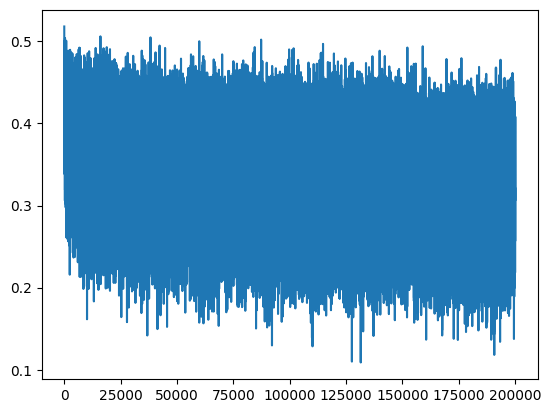

In [6]:
# plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))
plt.plot(lossi)

这里的损失函数看起来很奇怪，因为batch_size太小了，不够稳定，32个样本，有的批次运气好，有的就比较倒霉，导致损失函数看起来不太稳定

类似tensorboard等会对曲线进行平滑，这里也会对上面的值进行平均处理，从曲线中看到更有代表性的作用

torch.Size([200, 1000])


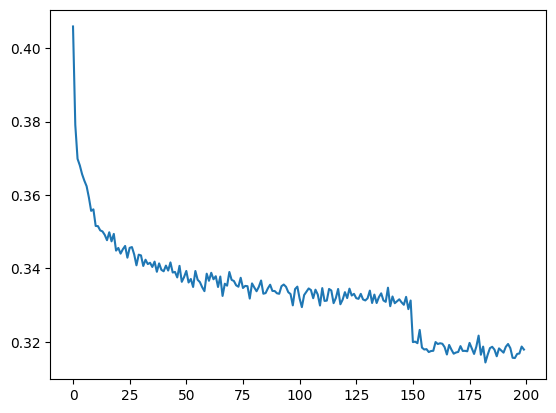

In [7]:
print(torch.tensor(lossi).view(-1, 1000).shape)
# 直接用view，把lossi这个20w的一维数组改成每连续的1000个数字一行的一个二维数组，一共200行
# 不要觉得 200和200平均之后，中间的连续性被破坏了~
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

`lr = 0.1 if i < 150000 else 0.01`

15k(上图 150 的地方是学习率发生改变的地方)， 从这里可以明显看出： 学习率衰减显著降低了系统的能量(参数熵的分散程度)，使我们可以在这个优化过程中稳定的收敛到局部最小值

In [8]:
# 由于有BN层的存在，因此，如果要进行评估/推理，需要设置training为False
# put layers into eval mode (needed for batchnorm especially)
for layer in layers:
  layer.training = False

In [9]:
# evaluate the loss
@torch.no_grad()
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) 
  for layer in layers:
      x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())
split_loss('train')
split_loss('val')

train 2.0583250522613525
val 2.1065289974212646


In [10]:
for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass:
      emb = C[torch.tensor([context])] # (1,block_size,d)      
      x = emb.view(emb.shape[0], -1) 
      for layer in layers:
          x = layer(x)
      logits = x
      # Sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

damiara.
alyzah.
fard.
azalee.
sayah.
ayvi.
reino.
sophemuellani.
ciaub.
alith.
sira.
liza.
jah.
grancealynna.
jamaur.
ben.
quan.
torie.
coria.
cer.


# 优化嵌入层+前向过程（代码一致性）

上面没有嵌入层，所以在写前向过程代码的时候，看起来很乱

## 补充嵌入层和Flatten层以及Sequential容器

In [3]:
class Embedding:
    # C = torch.randn((vocab_size, n_embd))
    # emb = C[Xb]
    # 主要就是实现这两个操作
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))
    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    def parameters(self):
        return [self.weight]   # 注意，这里要返回列表形式，不然下面遍历参数的时候就会有问题
  
class Flatten:
    # x = emb.view(emb.shape[0], -1) 
    # 主要就是实现这个操作
    def __call__(self, x):
        self.out =x.view(x.shape[0], -1)
        return self.out
    def parameters(self):
        return []

class Sequential:
    """详见: ## pytorch 容器类 (Sequential) 里关于容器的介绍，这里输入是个列表，不是 OrderedDict"""
    def __init__(self,layers):
        self.layers = layers
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

## 训练

In [12]:
torch.manual_seed(42) 
n_embd = 10 
n_hidden = 200 

model = Sequential([
  Embedding(vocab_size, n_embd), Flatten(),
  Linear(n_embd * block_size, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size)
])
with torch.no_grad():
  model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True  # 明确告知pytorch这些参数需要求梯度

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps): 
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) # loss function
    
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
    
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad
  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

12097
      0/ 200000: 3.2966
  10000/ 200000: 2.2322
  20000/ 200000: 2.4111
  30000/ 200000: 2.1004
  40000/ 200000: 2.3157
  50000/ 200000: 2.2104
  60000/ 200000: 1.9653
  70000/ 200000: 1.9767
  80000/ 200000: 2.6738
  90000/ 200000: 2.0837
 100000/ 200000: 2.2730
 110000/ 200000: 1.7491
 120000/ 200000: 2.2891
 130000/ 200000: 2.3443
 140000/ 200000: 2.1731
 150000/ 200000: 1.8246
 160000/ 200000: 1.7614
 170000/ 200000: 2.2419
 180000/ 200000: 2.0803
 190000/ 200000: 2.1326


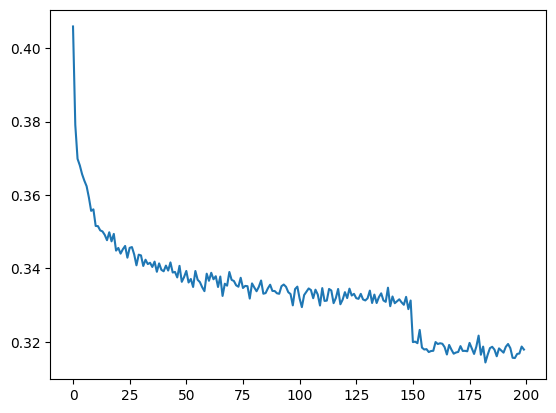

In [13]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

## 推理损失

In [14]:
for layer in model.layers:
  layer.training = False

In [15]:
@torch.no_grad()
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())
split_loss('train')
split_loss('val')

train 2.0583250522613525
val 2.1065289974212646


由于训练集和验证集上损失差不多，说明这个任务上没有出现过拟合，所以还可以继续扩大网络规模，比如增加网络的深度和宽度来进一步增加性能
+ 注意：这里的model结构只有一个 linear+BN+tanh 只有一个隐藏层，网络结构比较简单
+ 但是不管是增加层数，或者是增加每个层的神经元个数，都无法改变一个问题：
  + 即：嵌入层 是固定的，虽然可以增加嵌入维度，但是**嵌入层导致了模型一开始就将所有字符的信息压到一个层中**
  + 因此，本质上不是加深或者加宽，而是要修改网络结构

## BN层修改训练/推理模式（单个样本计算方差报错）

这里注意，如果没有提前运行：
```python
for layer in model.layers:
  layer.training = False
```
即： 没有将BN层设置为推理模式的话

如果试图`将单个样本输入到训练模式下的BN层`，则在推理时就会报错：
```bash
 xvar = x.var(dim, keepdim=True) # batch variance
---------------------------------------------------------------------------
RuntimeError                              Traceback (most recent call last)
Cell In[32], line 7
      5 logits = model(torch.tensor([context]))
      6 probs = F.softmax(logits, dim=1)
----> 7 ix = torch.multinomial(probs, num_samples=1).item()
      8 context = context[1:] + [ix]
      9 out.append(ix)

RuntimeError: probability tensor contains either `inf`, `nan` or element < 0
```
代码会在计算方差时报错，因为**单个样本的方差**的结果，无偏的时候不是一个number（除0错误），有偏的时候是0

| 类型 | 公式 | 单个样本时 |
|---|---|---|
| 总体方差 / 描述这一个数本身的离散程度 | $\frac{1}{n}\sum(x_i-\bar{x})^2$ | 0 |
| 样本方差 / 用来估计总体方差 | $\frac{1}{n-1}\sum(x_i-\bar{x})^2$ | 无法计算，因为除以 0 |

In [16]:
print(torch.var(torch.tensor([5.0]),correction = 0))
print(torch.var(torch.tensor([5.0]),correction = 1))

tensor(0.)
tensor(nan)


C:\Users\shanhuang\AppData\Local\Temp\ipykernel_36848\3328244902.py:2: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1831.)
  print(torch.var(torch.tensor([5.0]),correction = 1))


In [17]:
single_sample = torch.tensor([[5.0,3.0]])
bn = torch.nn.BatchNorm1d(2)
bn(single_sample)
# ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 2]) 
# 训练时每个通道要求有1个以上的值，即BatchSize>1, 而现在的输入size是 [1,2], 即：2个通道，但是每个通道只有一个值
# BatchNorm 在训练模式下要算的不是一个样本自己的方差，而是每个通道在整个 mini-batch 上的方差。 现在 batch size 是 1，每个通道只有一个数，所以没法算 batch 方差，PyTorch 直接报错。

ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 2])

## 推理生成结果

In [18]:
for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    print(''.join(itos[i] for i in out))

damiara.
alyzah.
fard.
azalee.
sayah.
ayvi.
reino.
sophemuellani.
ciaub.
alith.
sira.
liza.
jah.
grancealynna.
jamaur.
ben.
quan.
torie.
coria.
cer.


# 性能比较

老师在这里运行了一下，仅仅通过增加上下文长度（即：直接用上面这个 `block_size=8` 的数据集），去运行上面那个简单的网络，就获得了提升，得到以下结果，同时推理生成的名称看起来也更合理了
```bash
# context: 3 -> 8 (22K params)
train 1.91858...
val 2.02747...

# original (3 character context + 200 hidden neurons, 12K params)
train 2.0583250522613525
val 2.1065289974212646

# flat -> hierarchical (22K params): train 1.941, val 2.029

```

# WaveNet

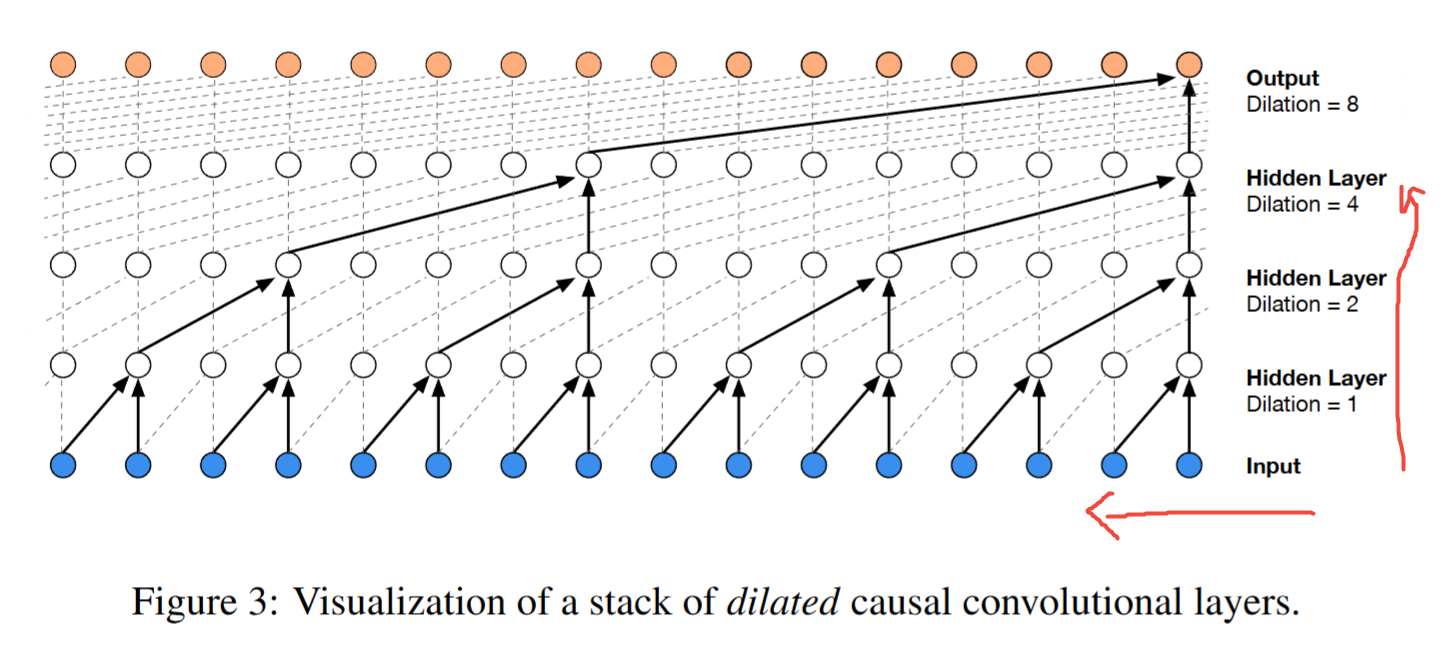

可以看到， WaveNet并不是一次性把输入字符全都进行处理(把信息全都压缩到嵌入矩阵中)，而是
1. 在第一个隐藏层的时候，把输入字符构成了类似2-gram的形式，逐步处理这一序列中的所有字符
2. 在第二个隐藏层的时候，把上一个隐藏层的继续2-gram，其实对应了输入的四个字符
3. 依次类推，有点像计算机视觉里的金字塔模型
4. **核心思想：渐进式融合(progressive fusion)**
   + 网络每加深一层，就仅融合相邻的两个元素(consecutive elements)

## 数据集构造修改

In [4]:
# 构造数据集，这里可以看到，上图一共是4层，输入是16个字符，经过四层后得到一个结果，即： 2^4=16
# 由于我们的数据集样本都比较短，所以设置输入是8个字符，3层即可
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

block_size = 8
Xtr,  Ytr  = build_dataset(words[:n1], block_size)     # 80%
Xdev, Ydev = build_dataset(words[n1:n2], block_size)   # 10%
Xte,  Yte  = build_dataset(words[n2:], block_size)     # 10%

for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

torch.Size([182580, 8]) torch.Size([182580])
torch.Size([22767, 8]) torch.Size([22767])
torch.Size([22799, 8]) torch.Size([22799])
........ --> e
.......e --> b
......eb --> r
.....ebr --> i
....ebri --> m
...ebrim --> a
..ebrima --> .
........ --> h
.......h --> i
......hi --> l
.....hil --> t
....hilt --> o
...hilto --> n
..hilton --> .
........ --> j
.......j --> h
......jh --> e
.....jhe --> n
....jhen --> e
...jhene --> .


## 网络中间维度设计考虑

**考虑如果要用`WaveNet`, 中间计算过程的维度该如何设置？**

In [22]:
print((torch.randn(4,80) @ torch.randn(80,200) + torch.randn(200)).shape)
print((torch.randn(4,5,80) @ torch.randn(80,200) + torch.randn(200)).shape)

torch.Size([4, 200])
torch.Size([4, 5, 200])


矩阵乘法只是固定最后一个维度就可以，所以前面有多少维无所谓。

根据`Wavenet`, 两两组合，所以这里希望的操作其实是分组并行，而不是一开始就把8个字符经过嵌入层，从(4,8,10)→(4,80)

例如： 一个样本是 [0,0,0,4,5,6,7,13] → [(0,0), (0,4), (5,6), (7,13)]

所以如果要用`Wavenet`的这套逻辑，经过嵌入层后的输入就变成了: (4,8,10)→(4,4,20), 与之相乘的下一个隐藏层的输入也是 20维了

这里我们压平的不是(8,10)→(80), 而是把8个字符两两一组，之后融合，即:(4,2,10)→(4,20)

In [23]:
print((torch.randn(4,4,20) @ torch.randn(20,200) + torch.randn(200)).shape)
# 4个样本 4组bigram经过隐藏层的结果

torch.Size([4, 4, 200])


In [5]:
e = torch.randn(4,8,10)  # 这是一个batch_size为4的输入经过嵌入层之后的维度
# print(e.view(4,-1).shape)  # torch.Size([4, 80]) 这是之前的flatten层完成的事情 

# 不过现在，要变成两两一组了
# 其实就是分别把偶数和奇数取出来，再合并
explicit = torch.cat((e[:,::2,:], e[:,1::2,:]), dim = 2)
print(e[:,::2,:].shape, e[:,1::2,:].shape, explicit.shape)

# (e.view(4,-1,2,10)).view(4, e.shape[1], -1).shape  # view() 不会修改原来的 e，e.shape[1] 始终是原始张量的第 2 维 8。 所以这里输出结果还是(4,8,10),而不是(4,4,20)
print((x := e.view(4, -1, 2, 10)).view(4, x.shape[1], -1).shape)  # 用海象运算符才可以

torch.Size([4, 4, 10]) torch.Size([4, 4, 10]) torch.Size([4, 4, 20])
torch.Size([4, 4, 20])


In [6]:
(e.view(4,4,20) == explicit).all()
# 即：上述方式得到的 是正确的

tensor(True)

## 配套组件修改

In [11]:
class FlattenConsecutive:
    # 为了和pytorch自带的Flatten区分，pytorch的Flatten完成的功能不是这个，为了保证接口的一致性，所以这里改个名字
    # 只会将连续的n个元素展平
    def __init__(self,n):
        # n: 最后一个维度拼接几个元素
        self.n = n
    def __call__(self, x):
        B, T, C = x.shape   # B：batch_size T:输入的字符个数(timestep / sequence length) C:每个字符的嵌入维度  例如：e = torch.randn(4,8,10) B=4个样本，T=8 输入是8个字符 C=10 一个字符是10个嵌入维度
        x = x.view(B, T//self.n, self.n*C)
        if x.shape[1] == 1:
            # 如果是之前那样，不是8个字符输入，而是3个字符输入，同时3个拼接，那么上面其实就是 (4,3,10)→(4,1,30) 这里会有个1，是个多余的维度
            x = x.squeeze()  # Returns a tensor with all specified dimensions of input of size 1 removed.
            # 为什么没有直接写成  x.view().squeeze()  因为 batch_size为1是不需要消除的，所以只有特定维度为1才需要删除
        # 老师这里的关键在于： 希望尽可能清晰的表达，所以view里用的都是很明确的维度信息，x.squeeze()也是明确是1
        self.out = x
        return self.out
    def parameters(self):
        return []

class BatchNorm1d:
  """
  以前写BN的时候，默认输入是二维的，即: (batch_size, num_features), 但是用了层次融合这种方法，BN的输入就变成了类似这样 BatchNorm1d : (4, 4, 68) 
  所以这时候，其实是要对 (B,T,C)的(T,C)维度上进行BN的
  """
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:  # 以前没有这个维度判断的
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

In [ ]:
a = torch.randn((4,2,4))  
print(a.mean((0,1), keepdim=True).shape)   # torch.Size([1, 1, 4])
b = torch.randn(4,8)
print(b.mean(0, keepdim=True).shape)      # torch.Size([1, 8])

# 为什么BN不修改也可以正常运行
e = torch.randn((32,4,68))
emean = e.mean(0, keepdim=True) 
print(emean.shape)                        # torch.Size([1, 4, 68])
evar = e.var(0, keepdim=True) 
print(evar.shape)                         # torch.Size([1, 4, 68])
ehat = (e - emean) / torch.sqrt(evar + 1e-5) 
print(ehat.shape)                        # torch.Size([32, 4, 68])
# 对于torch.randn((32,4,68))的输入，经过BN，我们期望得到的是(1,1,68)这样的mean和var，所以上面明显不对

## 训练

In [32]:
torch.manual_seed(42) 
n_embd = 10 
n_hidden = 68 

# 这样配置参数，就相当于以前的直接把8个输入一起展平，和3个输入一起展平是一样的情况
# model = Sequential([
#   Embedding(vocab_size, n_embd), FlattenConsecutive(block_size),
#   Linear(n_embd * block_size, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
#   Linear(n_hidden, vocab_size)
# ])
# 这样配置，就是wavenet了，这里需要注意，展平的时候是连续2个元素的话，那么线性层的输入也要变成 n_embd * 2
# 和之前算的一样，输入长度是8，那么只需要3层就可以两两融合完毕
model = Sequential([
  Embedding(vocab_size, n_embd), 
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size)
])
# 按照下面的例子，上面三个重复组件的输入和输出分别是： n_hidden从200改成了68
# 1输入 (4,8,10)， 输出(4,4,20)@(20,200) = (4,4,200)
# 2输入 (4,4,200), 输出(4,2,400)@(200*2,200) = (4,2,200)
# 3输入 (4,2,200), 输出(4,1,400)→(4,400)@(400,200) = (4,200)
with torch.no_grad():
  model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True  # 明确告知pytorch这些参数需要求梯度

22397


这里把 `n_hidden`从200改为68，是为了保证总参数数量和之前 输入改为8的时候，上面非WaveNet的网络的总参数也是这个scale规模的，方便之后比较性能, 对比：`# context: 3 -> 8 (22K params)`

这就可以说明： 这种架构可以更高效的利用参数/发挥参数的作用

观察一下每个模块/层的输出shape

In [33]:
ix = torch.randint(0, Xtr.shape[0], (4,))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
print(Xb)

for layer in model.layers:
    print(layer.__class__.__name__,":", tuple(layer.out.shape))

torch.Size([4, 8])
tensor([[ 0,  0,  0,  0, 16,  8,  9, 12],
        [ 0,  0,  0, 13,  1, 12,  3, 15],
        [ 0,  0,  0,  8,  5, 18, 13,  5],
        [ 1, 18,  9, 19, 20,  5, 12, 12]])
Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 68)
BatchNorm1d : (4, 4, 68)
Tanh : (4, 4, 68)
FlattenConsecutive : (4, 2, 136)
Linear : (4, 2, 68)
BatchNorm1d : (4, 2, 68)
Tanh : (4, 2, 68)
FlattenConsecutive : (4, 136)
Linear : (4, 68)
BatchNorm1d : (4, 68)
Tanh : (4, 68)
Linear : (4, 27)


In [34]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps): 
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) # loss function
    
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
    
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad
  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3078
  10000/ 200000: 2.2263
  20000/ 200000: 2.1137
  30000/ 200000: 1.7641
  40000/ 200000: 2.2798
  50000/ 200000: 2.0020
  60000/ 200000: 1.8360
  70000/ 200000: 2.4220
  80000/ 200000: 2.3907
  90000/ 200000: 2.3328
 100000/ 200000: 1.8891
 110000/ 200000: 2.3222
 120000/ 200000: 1.8952
 130000/ 200000: 1.9841
 140000/ 200000: 1.9518
 150000/ 200000: 1.8701
 160000/ 200000: 1.7911
 170000/ 200000: 2.2747
 180000/ 200000: 1.9497
 190000/ 200000: 1.9227


In [35]:
for layer in model.layers:
  layer.training = False

@torch.no_grad()
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())
split_loss('train')
split_loss('val')

train 1.9100755453109741
val 2.0182526111602783


# 其他

## pytorch 容器类 (Sequential)

[Containers](https://docs.pytorch.org/docs/2.13/nn.html#containers)
+ 容器：本质上就是将网络层或者参数，组织成列表或者字典等结构的方式
+ torch里包含：

|容器名称|说明|
|---|---|
|Module | Base class for all neural network modules.|
|Sequential | A sequential container.|
|ModuleList |Holds submodules in a `list`.|
|ModuleDict |Holds submodules in a `dictionary`.|
|ParameterList |Holds parameters in a `list`.|
|ParameterDict |Holds parameters in a `dictionary`.|


其中最常用的是 `Sequential` 这个类型的容器， [class torch.nn.Sequential(arg: OrderedDict[str, Module])](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Sequential.html#torch.nn.Sequential)
+ 这个容器的作用： 把给定的输入按顺序依次通过所有层进行处理
+ `Sequential` 和 `torch.nn.ModuleList` 有什么区别？ModuleList 正如其名，就是用来存储模块的列表！而 Sequential 中的层则是以`级联`(cascading)方式连接的。
  + 这里的 “级联”（cascading） 可以理解为：下一个模块的输入，是上一个模块的输出。也就是数据按顺序一层一层传下去。

## 多维数组维度的意义

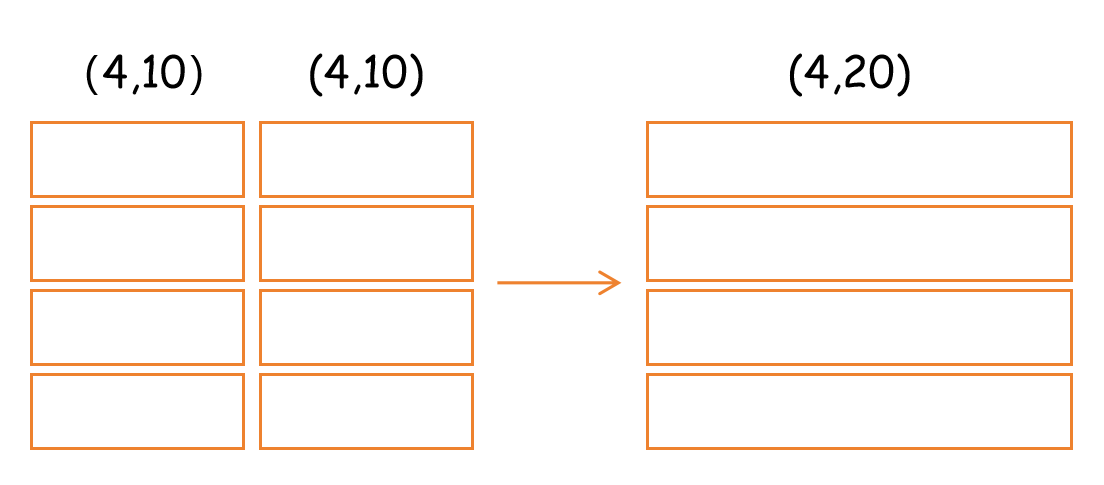

不要去纠结，(4,10)拼接(4,10)变成(4,20), 有一个4好像被吞了一样。。。其实就是类似上图

而且对于多维数组，本质上这个维度描述，`(4,4,10)其实就是把一个一维数组，手动分行/分组，有数的地方只在10那个维度的括号里`，其余的`(4,4)`其实就是规定分组的，没有实际意义，有意义的只有10那个维度包裹的数据~

## Image Pyramids

+ [tutorial_pyramids- Image Pyramids](https://docs.opencv.org/3.4.12/d4/d1f/tutorial_pyramids.html)
+ [tutorials/Image_Processing/7_Image_Pyramids/README.md](https://github.com/Hank-Tsou/Computer-Vision-OpenCV-Python/blob/master/tutorials/Image_Processing/7_Image_Pyramids/README.md)
+ [Docs » 4. OpenCV中的图像处理 » 4.8. 图像金字塔](https://opencv-python-tutorials.readthedocs.io/zh/latest/4.%20OpenCV%E4%B8%AD%E7%9A%84%E5%9B%BE%E5%83%8F%E5%A4%84%E7%90%86/4.8.%20%E5%9B%BE%E5%83%8F%E9%87%91%E5%AD%97%E5%A1%94/)
+ [OpenCV-Python 教程 -> OpenCV 中的图像处理](https://docs.opencv.ac.cn/5.0/py_tutorials/py_imgproc/py_pyramids/py_pyramids.html)

## dilated causal convolutional layers